In [108]:
# API to fetch the dataset from Kaggle
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
face-mask-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [109]:
# extracting the compessed Dataset
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [110]:
!ls

data  face-mask-dataset.zip  sample_data


Importing the dependencies

In [111]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [112]:
with_mask=os.listdir('/content/data/with_mask')
print(with_mask[0:5])
print(with_mask[-5:])

['with_mask_3669.jpg', 'with_mask_1244.jpg', 'with_mask_2664.jpg', 'with_mask_1434.jpg', 'with_mask_2431.jpg']
['with_mask_1440.jpg', 'with_mask_916.jpg', 'with_mask_1167.jpg', 'with_mask_1188.jpg', 'with_mask_794.jpg']


In [113]:
without_mask=os.listdir('/content/data/without_mask')
print(without_mask[0:5])

['without_mask_510.jpg', 'without_mask_1637.jpg', 'without_mask_746.jpg', 'without_mask_1418.jpg', 'without_mask_3485.jpg']


In [114]:
print('Number of with mask images:',len(with_mask))
print('Number of without mask images:',len(without_mask))

Number of with mask images: 3725
Number of without mask images: 3828


Creating labels for images


with mask -> 1
without mask -> 0


In [115]:
#create labels
with_mask_labels=[1]*3725
without_mask_labels=[0]*3828

In [116]:
labels=with_mask+without_mask
print(len(labels))
print(with_mask_labels[0:5])
print(without_mask_labels[0:5])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [117]:
print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3828


Displaying the images


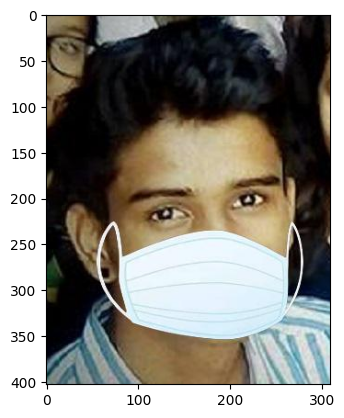

In [118]:
#displaying with mask image
img=mpimg.imread('/content/data/with_mask/with_mask_1000.jpg')
imgplot=plt.imshow(img)
plt.show()

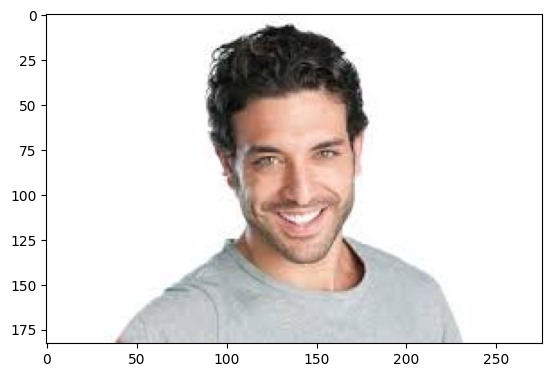

In [119]:
#displaying without mask image
img=mpimg.imread('/content/data/without_mask/without_mask_1000.jpg')
imgplot=plt.imshow(img)
plt.show()

Image processing


1. Re-size the image

  2. Convert images to numpy array

In [120]:
# convert images to numpy arrays+

with_mask_path = '/content/data/with_mask'
without_mask_path = '/content/data/without_mask'

with_mask = os.listdir(with_mask_path)
without_mask = os.listdir(without_mask_path)

data = []

for img_file in with_mask:
    image = Image.open(os.path.join(with_mask_path, img_file))
    image = image.resize((128,128))
    image = image.convert('RGB')
    data.append(np.array(image))

for img_file in without_mask:
    image = Image.open(os.path.join(without_mask_path, img_file))
    image = image.resize((128,128))
    image = image.convert('RGB')
    data.append(np.array(image))

In [121]:
type(data)

list

In [122]:
len(data)

7553

array([[[235, 244, 251],
        [236, 245, 252],
        [236, 245, 252],
        ...,
        [245, 248, 253],
        [245, 248, 253],
        [245, 248, 253]],

       [[235, 244, 251],
        [236, 245, 252],
        [236, 245, 252],
        ...,
        [245, 248, 253],
        [245, 248, 253],
        [245, 248, 253]],

       [[235, 244, 251],
        [236, 245, 252],
        [236, 245, 252],
        ...,
        [245, 249, 253],
        [245, 249, 253],
        [245, 248, 253]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
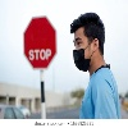

In [123]:
data[0]

In [124]:
type(data[0])

numpy.ndarray

In [125]:
data[0].shape

(128, 128, 3)

In [126]:
# converting image list and label list to numpy arrays

X = np.array(data)
Y = np.array(labels)

In [127]:
type(X)
type(Y)

numpy.ndarray

In [128]:
print(X.shape)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


In [129]:
print(Y)

['with_mask_3669.jpg' 'with_mask_1244.jpg' 'with_mask_2664.jpg' ...
 'without_mask_1036.jpg' 'without_mask_462.jpg' 'without_mask_3477.jpg']


Train Test Split


In [130]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [131]:
print(X.shape, X_train.shape, X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [132]:
# scaling the data

X_train_scaled = X_train/255

X_test_scaled = X_test/255

array([[[229, 221, 236],
        [229, 221, 236],
        [229, 221, 236],
        ...,
        [185, 112, 103],
        [189, 110, 103],
        [188, 109, 102]],

       [[228, 220, 235],
        [228, 220, 235],
        [228, 220, 235],
        ...,
        [186, 111, 102],
        [189, 109, 102],
        [189, 110, 103]],

       [[227, 219, 234],
        [228, 220, 235],
        [228, 220, 235],
        ...,
        [186, 108, 101],
        [190, 107, 102],
        [192, 107, 103]],

       ...,

       [[207, 151, 124],
        [206, 150, 123],
        [206, 150, 125],
        ...,
        [153, 153, 171],
        [159, 158, 175],
        [161, 160, 177]],

       [[206, 150, 123],
        [206, 150, 123],
        [206, 150, 125],
        ...,
        [157, 155, 173],
        [158, 157, 174],
        [160, 159, 175]],

       [[206, 150, 123],
        [206, 150, 123],
        [206, 150, 125],
        ...,
        [157, 156, 173],
        [159, 158, 174],
        [160, 159, 175]]], dtype=uint8)
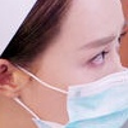

In [133]:
X_train[0]

Building Convolutional Neural Network


In [134]:
import tensorflow as tf
from tensorflow import keras

In [135]:
num_of_classes=2
model=keras.Sequential()
model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))


model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))


model.add(keras.layers.Dense(num_of_classes, activation='sigmoid'))

In [136]:
# compile the neural network
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

In [137]:
Y_train = np.array([1 if 'with_mask' in x else 0 for x in Y_train])
Y_test  = np.array([1 if 'with_mask' in x else 0 for x in Y_test])

print(np.unique(Y_train))
print(np.unique(Y_test))

[0 1]
[0 1]


In [145]:
# training the neural network
history = model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs=5)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - acc: 0.9364 - loss: 0.1688 - val_acc: 0.9223 - val_loss: 0.1975
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - acc: 0.9487 - loss: 0.1414 - val_acc: 0.9273 - val_loss: 0.1808
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.9592 - loss: 0.1078 - val_acc: 0.9289 - val_loss: 0.1864
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.9610 - loss: 0.0974 - val_acc: 0.9207 - val_loss: 0.2591
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.9673 - loss: 0.0952 - val_acc: 0.9289 - val_loss: 0.2378


Model Evaluation

In [139]:
loss,accuracy=model.evaluate(X_test_scaled,Y_test)
print('Test Accuracy =',accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.9365 - loss: 0.1731
Test Accuracy = 0.9364659190177917


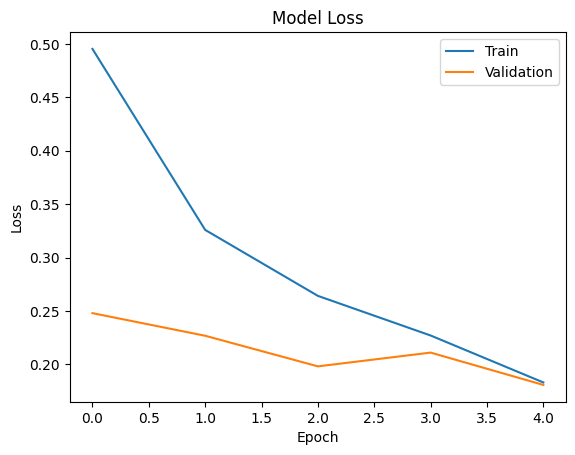

In [140]:
h=history

#ploting the loss value
plt.plot(h.history['loss'])
plt.plot(h.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

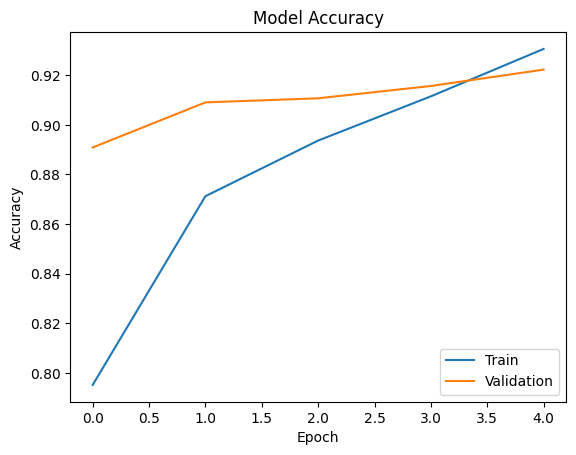

In [141]:
#ploting the accuracy value
plt.plot(h.history['acc'])
plt.plot(h.history['val_acc'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()

Predictive System

Path of the image to be predicted: /content/data/with_mask/with_mask_1003.jpg


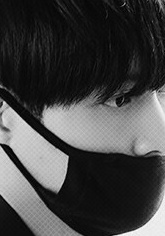

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
[[0.00777783 0.9766282 ]]
1
The person in the image is not wearing a mask


In [144]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 0:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')